In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress


In [2]:
hun_temp = pd.read_csv('../data/processed/hungary_temperatures_processed.csv')
hun_temp.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year,month,day,season,is_above_mean,temp_lag_1,temp_lag_12,temp_roll_mean_3
0,1901-01-01,-6.181,0.794,Hungary,1901,1,1,Winter,0,0.732,0.325,6.051333
1,1901-02-01,-3.524,0.461,Hungary,1901,2,1,Winter,0,-6.181,3.874,0.404667
2,1901-03-01,5.078,0.315,Hungary,1901,3,1,Spring,0,-3.524,2.063,-2.991000
3,1901-04-01,10.005,0.460,Hungary,1901,4,1,Spring,1,5.078,9.030,-1.542333
4,1901-05-01,15.464,0.170,Hungary,1901,5,1,Spring,1,10.005,14.282,3.853000


In [3]:
hun_temp['AverageTemperature'].describe()

count    1352.000000
mean        9.996179
std         8.129014
min        -9.819000
25%         2.631250
50%        10.263500
75%        17.668500
max        24.934000
Name: AverageTemperature, dtype: float64

In [4]:
hun_temp['AverageTemperatureUncertainty'].mean()

np.float64(0.333335798816568)

In [5]:
hottest_month = hun_temp.loc[hun_temp['AverageTemperature'].idxmax()]
coldest_month = hun_temp.loc[hun_temp['AverageTemperature'].idxmin()]
print(f"hottest month in Hungary: {hottest_month} \n Coldest month in Hungary: {coldest_month}")

hottest month in Hungary: dt                               1992-08-01
AverageTemperature                   24.934
AverageTemperatureUncertainty         0.264
Country                             Hungary
year                                   1992
month                                     8
day                                       1
season                               Summer
is_above_mean                             1
temp_lag_1                           21.607
temp_lag_12                          20.117
temp_roll_mean_3                  19.060333
Name: 1099, dtype: object 
 Coldest month in Hungary: dt                               1942-01-01
AverageTemperature                   -9.819
AverageTemperatureUncertainty         0.385
Country                             Hungary
year                                   1942
month                                     1
day                                       1
season                               Winter
is_above_mean                           

In [6]:
temp_wide= hun_temp.pivot(index='year',columns='month',values='AverageTemperature')
temp_wide.head()

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1901,-6.181,-3.524,5.078,10.005,15.464,19.606,21.138,19.359,15.054,11.116,2.813,2.711
1902,1.537,1.803,4.239,9.152,11.555,17.523,19.242,19.745,15.200,9.672,0.792,-4.575
1903,-2.403,2.678,7.206,7.661,15.080,17.561,19.609,19.017,15.931,10.625,5.404,1.039
1904,-2.848,2.642,4.925,10.386,14.827,18.621,21.845,20.124,14.352,10.157,2.373,0.457
1905,-5.516,-0.334,5.442,8.350,15.295,19.362,21.957,21.215,16.883,6.033,5.917,0.276


In [21]:
hun_temp.groupby("season")["AverageTemperature"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
season,,,,,
Autumn,10.242848,10.1740,4.899080,-0.467,19.199
Spring,10.349386,10.3240,4.675869,-0.307,19.329
Summer,19.882566,19.8430,1.509039,15.712,24.934
Winter,-0.518920,-0.2185,2.727330,-9.819,5.621


In [25]:
yearly = hun_temp.groupby("year")["AverageTemperature"].mean()
result = linregress(yearly.index, yearly.values)

print("Slope:", result.slope)
print("p-value:", result.pvalue)
print("R²:", result.rvalue**2)

Slope: 0.011720114029542893
p-value: 9.053199322782353e-09
R²: 0.2583806624127597


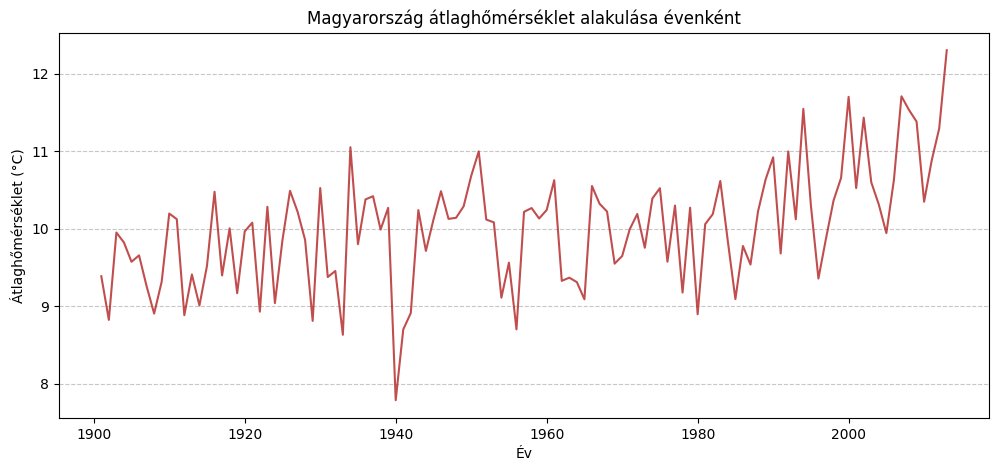

In [7]:
yearly_temp=hun_temp.groupby('year')['AverageTemperature'].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly_temp.index, yearly_temp.values, color='firebrick', alpha=0.8)

plt.title('Magyarország átlaghőmérséklet alakulása évenként')
plt.xlabel('Év')
plt.ylabel('Átlaghőmérséklet (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

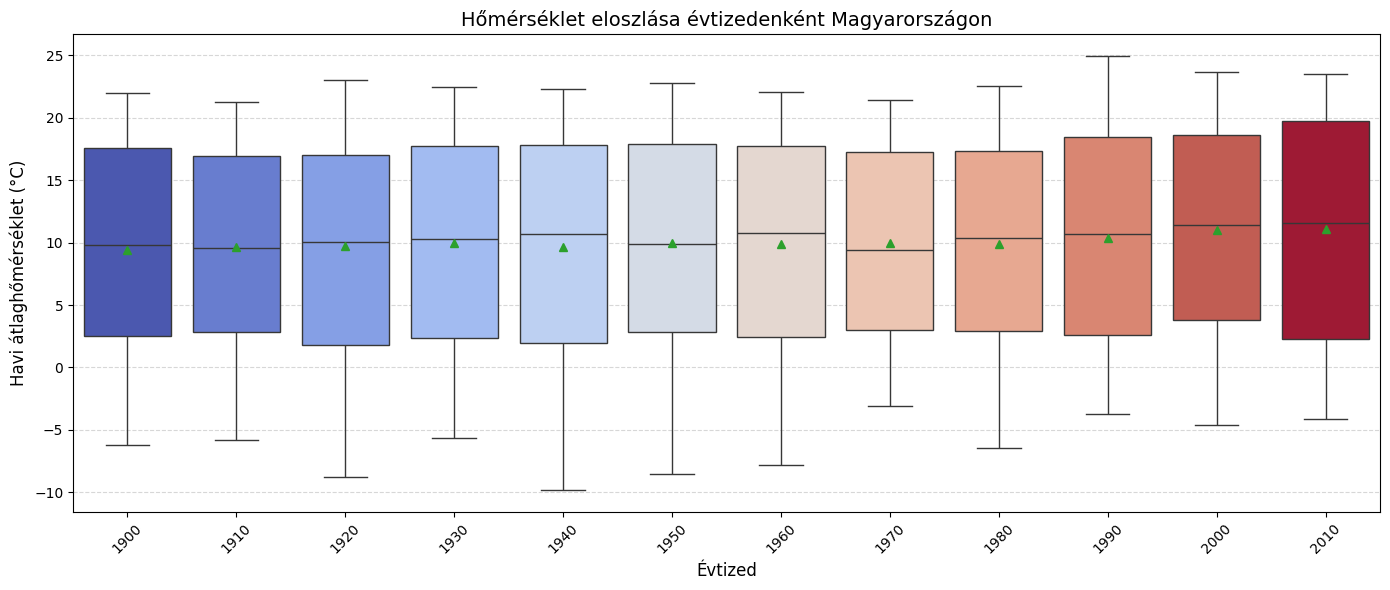

In [8]:
hun_temp['decade'] = (hun_temp['year'] // 10) * 10

# 2. Ábra méretezése
plt.figure(figsize=(14, 6))


sns.boxplot(
    data=hun_temp, 
    x='decade', 
    y='AverageTemperature', 
    hue='decade',        
    legend=False,        
    palette='coolwarm',
    showmeans=True
)


plt.title('Hőmérséklet eloszlása évtizedenként Magyarországon', fontsize=14)
plt.xlabel('Évtized', fontsize=12)
plt.ylabel('Havi átlaghőmérséklet (°C)', fontsize=12)
plt.xticks(rotation=45) # X tengely feliratainak elforgatása a jobb olvashatóságért
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

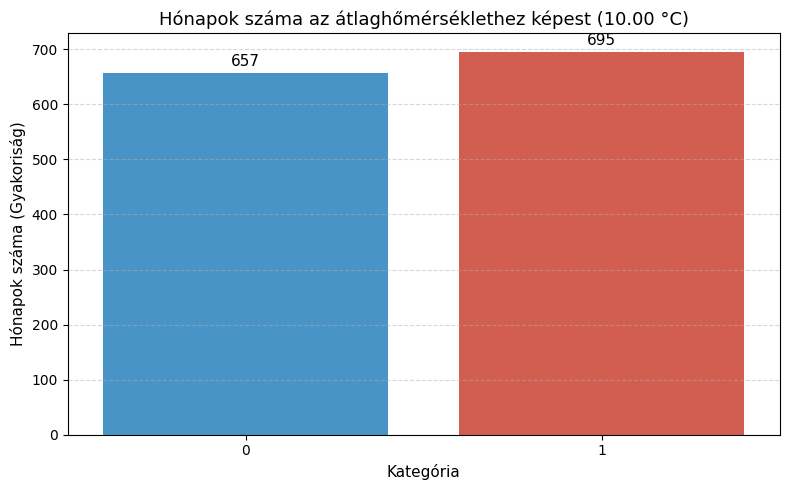

In [10]:

mean_temp = hun_temp['AverageTemperature'].mean()
# 3. Countplot kirajzolása
plt.figure(figsize=(8, 5))
sns.countplot(
    data=hun_temp, 
    x='is_above_mean', 
    hue='is_above_mean',
    palette=['#3498db', '#e74c3c'],  # Kék az átlag alatti, piros az átlag feletti
    legend=False
)

# 4. Formázás
plt.title(f'Hónapok száma az átlaghőmérséklethez képest ({mean_temp:.2f} °C)', fontsize=13)
plt.xlabel('Kategória', fontsize=11)
plt.ylabel('Hónapok száma (Gyakoriság)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Pontos értékek kiírása az oszlopok tetejére
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=11, xytext=(0, 3), 
                        textcoords='offset points')

plt.tight_layout()
plt.savefig('../reports/figures/hungary_above_below_mean_count.png', dpi=300)
plt.show()

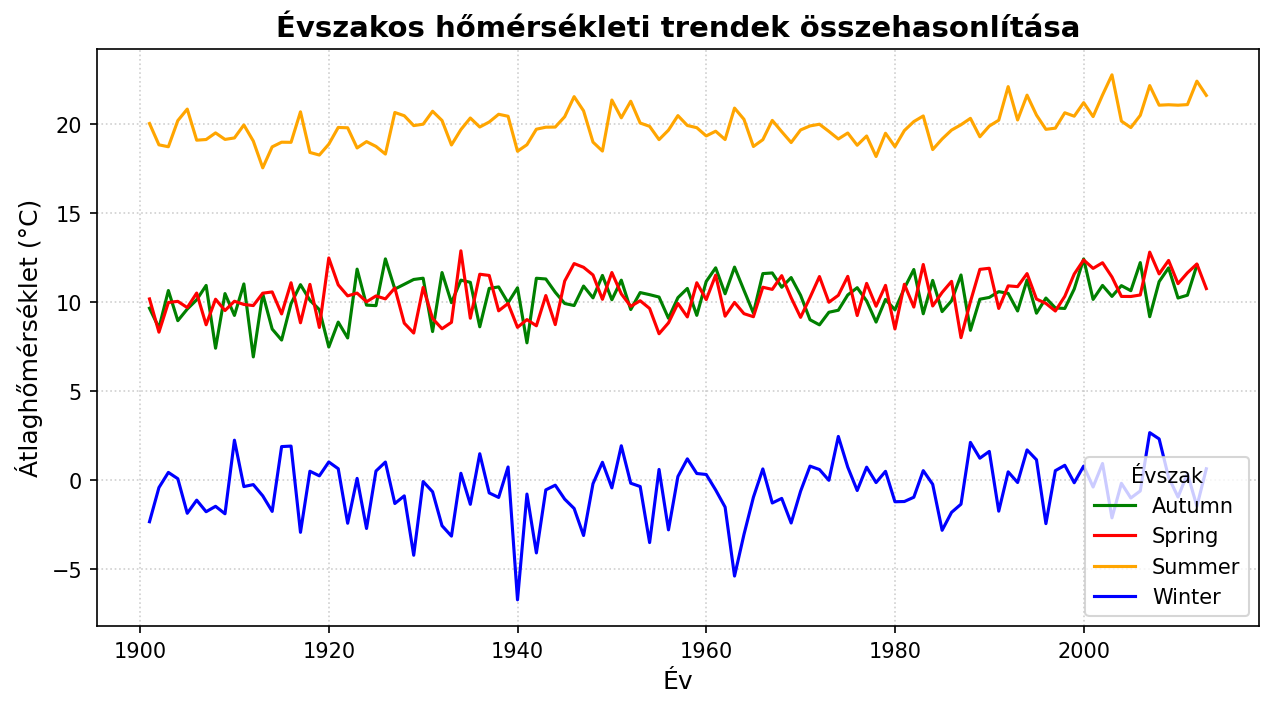

In [15]:
seasonal_yearly = (
    hun_temp.groupby(['year', 'season'])['AverageTemperature']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5), dpi=150)

# Seaborn vonaldiagram a 4 évszakra külön színnel
sns.lineplot(
    data=seasonal_yearly,
    x='year',
    y='AverageTemperature',
    hue='season',
    palette=['g', 'r', 'orange', 'b'],
)

plt.title(
    'Évszakos hőmérsékleti trendek összehasonlítása',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Év', fontsize=12)
plt.ylabel('Átlaghőmérséklet (°C)', fontsize=12)
plt.legend(title='Évszak')
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('../reports/figures/Seasonal_Temperature_Trends.png', dpi=300)
plt.show()

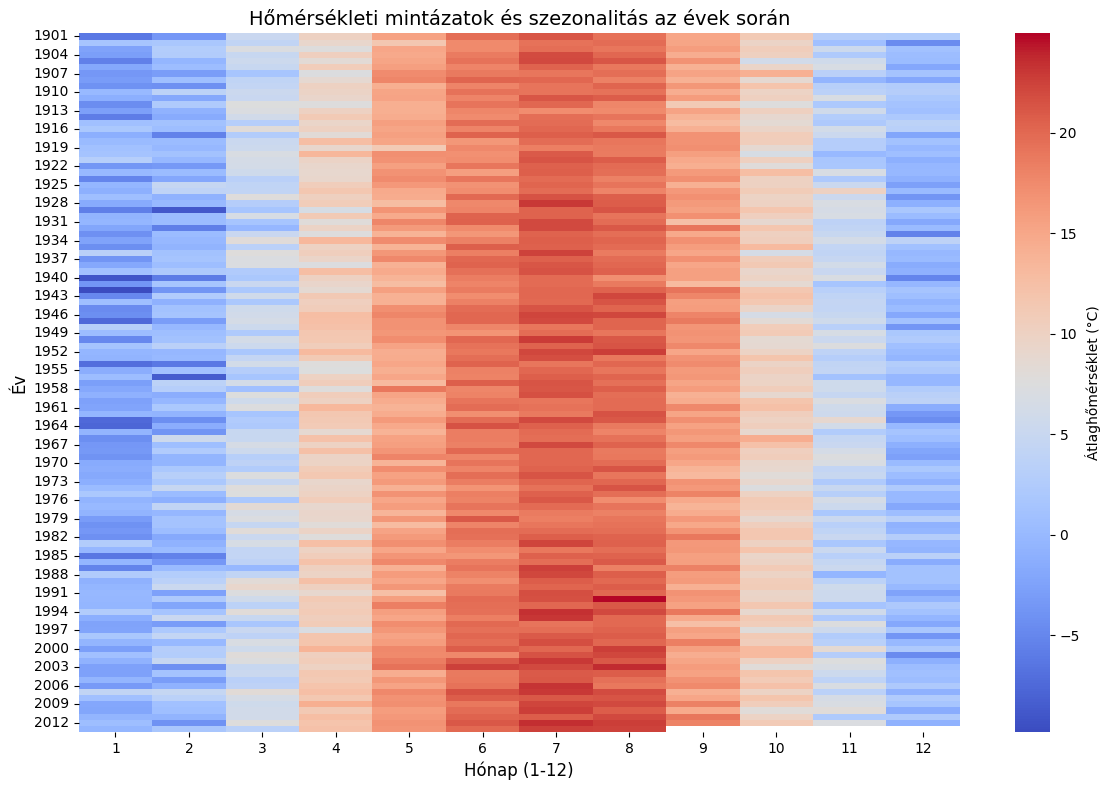

In [16]:
heatmap_data = hun_temp.pivot_table(
    values='AverageTemperature', 
    index='year', 
    columns='month', 
    aggfunc='mean'
)
plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data, 
    cmap='coolwarm', 
    cbar_kws={'label': 'Átlaghőmérséklet (°C)'}
)

# Címek és tengelyfeliratok
plt.title('Hőmérsékleti mintázatok és szezonalitás az évek során', fontsize=14)
plt.xlabel('Hónap (1-12)', fontsize=12)
plt.ylabel('Év', fontsize=12)

plt.savefig('../reports/figures/Temperature_Patterns_Seasonality.png', dpi=300)

plt.tight_layout()

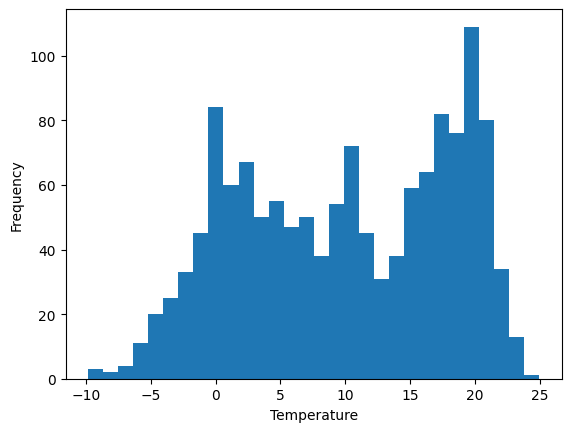

In [13]:
plt.hist(hun_temp["AverageTemperature"], bins=30)
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

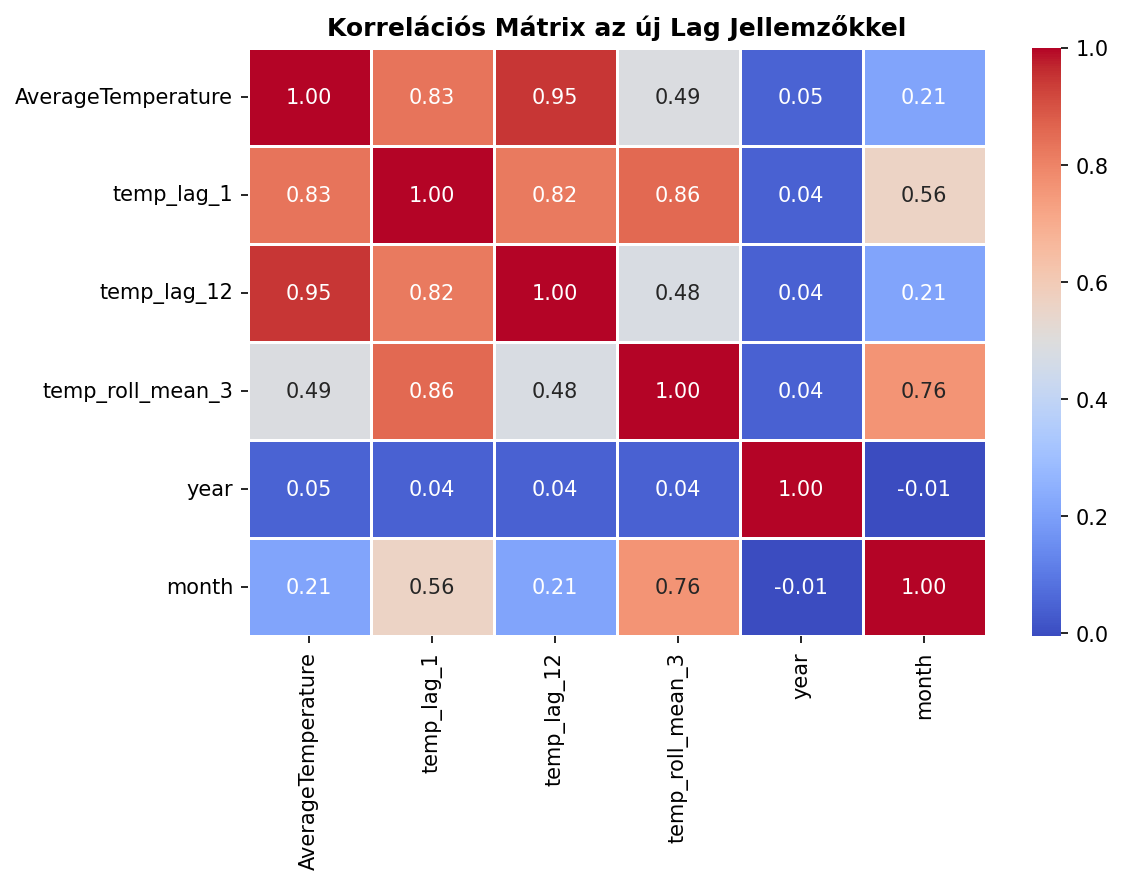

In [14]:
# Új numerikus oszlopok kijelölése
lag_cols = [
    'AverageTemperature',
    'temp_lag_1',
    'temp_lag_12',
    'temp_roll_mean_3',
    'year',
    'month',
]

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    hun_temp[lag_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
)
plt.title(
    'Korrelációs Mátrix az új Lag Jellemzőkkel', fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()